In [1]:
import os
import random
from pathlib import Path

import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [4]:
dataset_path = Path(r"C:\Users\LENOVO\OneDrive\Desktop\SmartAgroAI\dataset\plantvillage dataset\color")

print(dataset_path.exists())

True


In [5]:
# Get all class (disease) folders

class_names = sorted(
    [folder.name for folder in dataset_path.iterdir() if folder.is_dir()]
)

print(f"Number of classes: {len(class_names)}")
print("\nDisease Classes:\n")

for i, class_name in enumerate(class_names, start=1):
    print(f"{i}. {class_name}")

Number of classes: 38

Disease Classes:

1. Apple___Apple_scab
2. Apple___Black_rot
3. Apple___Cedar_apple_rust
4. Apple___healthy
5. Blueberry___healthy
6. Cherry_(including_sour)___Powdery_mildew
7. Cherry_(including_sour)___healthy
8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
9. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight
11. Corn_(maize)___healthy
12. Grape___Black_rot
13. Grape___Esca_(Black_Measles)
14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15. Grape___healthy
16. Orange___Haunglongbing_(Citrus_greening)
17. Peach___Bacterial_spot
18. Peach___healthy
19. Pepper,_bell___Bacterial_spot
20. Pepper,_bell___healthy
21. Potato___Early_blight
22. Potato___Late_blight
23. Potato___healthy
24. Raspberry___healthy
25. Soybean___healthy
26. Squash___Powdery_mildew
27. Strawberry___Leaf_scorch
28. Strawberry___healthy
29. Tomato___Bacterial_spot
30. Tomato___Early_blight
31. Tomato___Late_blight
32. Tomato___Leaf_Mold
33. Tomato___Septoria_leaf_spot
34. 

In [6]:
import random

# Pick a random disease folder
random_class = random.choice(class_names)

# Get all images inside that folder
image_files = list((dataset_path / random_class).glob("*"))

# Pick one random image
random_image = random.choice(image_files)

print("Disease:", random_class)
print("Image:", random_image.name)

Disease: Tomato___Early_blight
Image: f547a0f4-912a-45ec-81aa-371ad12ecacf___RS_Erly.B 7608.JPG


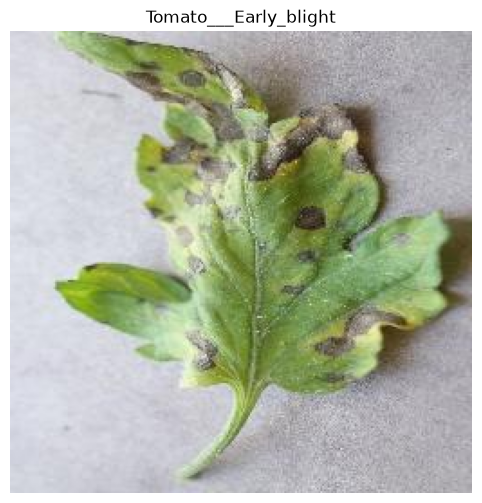

In [7]:
image = plt.imread(random_image)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title(random_class)
plt.axis("off")

plt.show()

In [8]:
print(image.shape)

(256, 256, 3)


In [ ]:
print(image[0][0])

[166 162 179]


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.


In [ ]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [ ]:
print(train_dataset)
print(validation_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [ ]:
# Get one batch
images, labels = next(iter(train_dataset))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


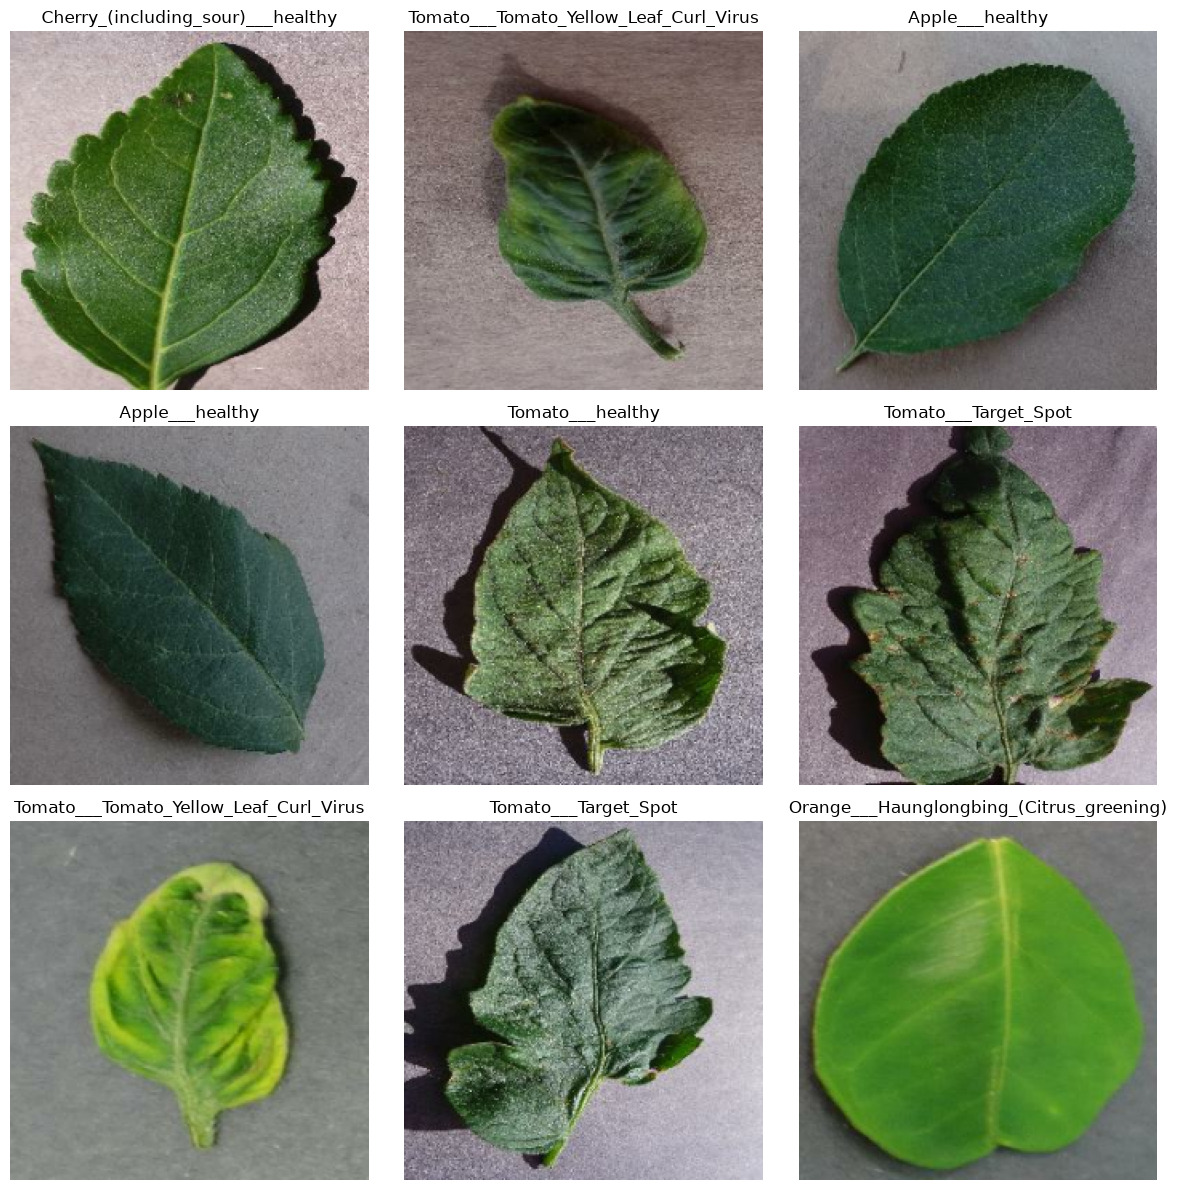

In [ ]:
plt.figure(figsize=(12, 12))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()